# OWS Styling

Reference pages on testing styling in a notebook before switching to the datacube ows config:
- Applying style to xarray Dataset: https://datacube-ows.readthedocs.io/en/latest/cfg_style_api.html
- Testing styles in notebook: https://datacube-ows.readthedocs.io/en/latest/styling_howto.html
- Color ramp: https://datacube-ows.readthedocs.io/en/latest/style_howto_color_ramp.html
- Legends: https://datacube-ows.readthedocs.io/en/latest/style_howto_legends.html

In [1]:
from datacube import Datacube
# Area of interest
from importlib.resources import files
import geopandas as gpd
from odc.geo.geom import Geometry

In [2]:
dc = Datacube()

In [3]:
# View product description
products_df = dc.list_products()
products_df[products_df["name"].isin(["wq_annual"])]

,name,description,license,default_crs,default_resolution
name,,,,,
wq_annual,wq_annual,DE Africa Water Quality Service annual water q...,CC-BY-4.0,EPSG:6933,"Resolution(x=10, y=-10)"


In [4]:
# List measurements
measurements_df = dc.list_measurements()
measurements_df.query("product == 'wq_annual'")

name    dtype units nodata aliases  \
product   measurement                                                
wq_annual agm_fai            agm_fai  float32     1    NaN     NaN   
          agm_hue            agm_hue  float32     1    NaN     NaN   
          agm_ndvi          agm_ndvi  float32     1    NaN     NaN   
          agm_owt            agm_owt  float32     1    NaN     NaN   
          chla                  chla  float32     1    NaN     NaN   
          clear_water    clear_water  float32     1    NaN     NaN   
          msi_agm_fai    msi_agm_fai  float32     1    NaN     NaN   
          msi_agm_hue    msi_agm_hue  float32     1    NaN     NaN   
          msi_agm_ndvi  msi_agm_ndvi  float32     1    NaN     NaN   
          msi_agm_owt    msi_agm_owt  float32     1    NaN     NaN   
          oli_agm_fai    oli_agm_fai  float32     1    NaN     NaN   
          oli_agm_hue    oli_agm_hue  float32     1    NaN     NaN   
          oli_agm_ndvi  oli_agm_ndvi  float32     1    NaN     NaN   
          oli_agm_owt    oli_agm_owt  float32     1    NaN     NaN   
          tm_agm_fai      tm_agm_fai  float32     1    NaN     NaN   
          tm_agm_hue      tm_agm_hue  float32     1    NaN     NaN   
          tm_agm_ndvi    tm_agm_ndvi  float32     1    NaN     NaN   
          tm_agm_owt      tm_agm_owt  float32     1    NaN     NaN   
          tsi                    tsi  float32     1    NaN     NaN   
          tsm                    tsm  float32     1    NaN     NaN   
          water_mask      water_mask  float32     1    NaN     NaN   

                       flags_definition  add_offset  scale_factor  
product   measurement                                              
wq_annual agm_fai                   NaN         0.0           1.0  
          agm_hue                   NaN         0.0           1.0  
          agm_ndvi                  NaN         0.0           1.0  
          agm_owt                   NaN         0.0           1.0  
          chla                      NaN         0.0           1.0  
          clear_water               NaN         0.0           1.0  
          msi_agm_fai               NaN         0.0           1.0  
          msi_agm_hue               NaN         0.0           1.0  
          msi_agm_ndvi              NaN         0.0           1.0  
          msi_agm_owt               NaN         0.0           1.0  
          oli_agm_fai               NaN         0.0           1.0  
          oli_agm_hue               NaN         0.0           1.0  
          oli_agm_ndvi              NaN         0.0           1.0  
          oli_agm_owt               NaN         0.0           1.0  
          tm_agm_fai                NaN         0.0           1.0  
          tm_agm_hue                NaN         0.0           1.0  
          tm_agm_ndvi               NaN         0.0           1.0  
          tm_agm_owt                NaN         0.0           1.0  
          tsi                       NaN         0.0           1.0  
          tsm                       NaN         0.0           1.0  
          water_mask                NaN         0.0           1.0

In [14]:
places_fp = "places.parquet"
places_gdf = gpd.read_parquet(places_fp)
place_name_list = places_gdf["name"].to_list()

place_name = "SA_smalldam1"
place = places_gdf[places_gdf["name"].isin([place_name])]
aoi_geom = Geometry(geom=place.iloc[0].geometry, crs=place.crs)

In [15]:
aoi_geom.explore()

In [16]:
ds = dc.load(
    product="wq_annual",
    time=("2024"),
    geopolygon=aoi_geom,
    measurements=["tsm"],
    output_crs="EPSG:6933",
    resolution=(-10,10)
)
ds

<xarray.Dataset> Size: 8kB
Dimensions:      (time: 1, y: 39, x: 49)
Coordinates:
  * time         (time) datetime64[ns] 8B 2024-07-01T23:59:59.999999
  * y            (y) float64 312B -4.072e+06 -4.072e+06 ... -4.073e+06
  * x            (x) float64 392B 1.882e+06 1.882e+06 ... 1.882e+06 1.882e+06
    spatial_ref  int32 4B 6933
Data variables:
    tsm          (time, y, x) float32 8kB nan nan nan nan ... nan nan nan nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

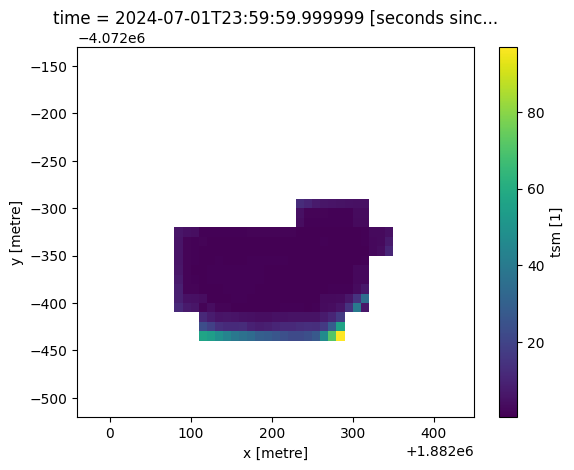

In [17]:
ds["tsm"].plot()

In [18]:
from datacube_ows.styles.api import StandaloneStyle, apply_ows_style_cfg, xarray_image_as_png,plot_image_with_style_cfg

In [19]:
color_ramp_tsm = [
    {"value": 0.0, "color": "#084594"},  # 0 mg/L - Navy
    {"value": 10.0, "color": "#2171b5"},  # 10 mg/L - Blue
    {"value": 25.0, "color": "#4292c6"},  # 25 mg/L - Light blue
    {"value": 50.0, "color": "#6baed6"},  # 50 mg/L - Pale blue
    {"value": 75.0, "color": "#9ecae1"},  # 75 mg/L - Very pale blue
    {"value": 100.0, "color": "#deebf7"},  # 100 mg/L - Almost white blue
    {"value": 125.0, "color": "#ffffcc"},  # 125 mg/L - Pale yellow
    {"value": 150.0, "color": "#ffeda0"},  # 150 mg/L - Light yellow
    {"value": 175.0, "color": "#fed976"},  # 175 mg/L - Yellow
    {"value": 200.0, "color": "#feb24c"},  # 200 mg/L - Orange
    {"value": 225.0, "color": "#fd8d3c"},  # 225 mg/L - Dark orange
    {"value": 250.0, "color": "#fc4e2a"},  # 250 mg/L - Red-orange
    {"value": 275.0, "color": "#e31a1c"},  # 275 mg/L - Red
    {"value": 300.0, "color": "#bd0026"},  # 300 mg/L - Dark red
    {"value": 400.0, "color": "#800026"},  # 400+ mg/L - Very dark red
]

In [20]:
legend = {
        "show_legend": True,
        "title": "Total Suspended Matter",
        "units": "mg/L",
        # Ticks at 0.0, 0.5 and 1.0
        "begin": "0.0",
        "end": "500.0",
        "decimal_places": 1,
        "ticks_every": "100",
        "width": 4.5,
        "height": 2.1,
        "strip_location": [0.1, 0.4, 0.8, 0.2],
    }

In [21]:
custom_ramp_cfg = {
    "index_function": {
        "function": "datacube_ows.band_utils.single_band",
        "mapped_bands": True,
        "kwargs": {"band": "tsm"},
    },
    "color_ramp": color_ramp_tsm,
    "legend": legend
}

In [22]:
from datacube_ows.styles.api import generate_ows_legend_style_cfg

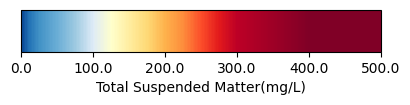

In [23]:
image = generate_ows_legend_style_cfg(custom_ramp_cfg)

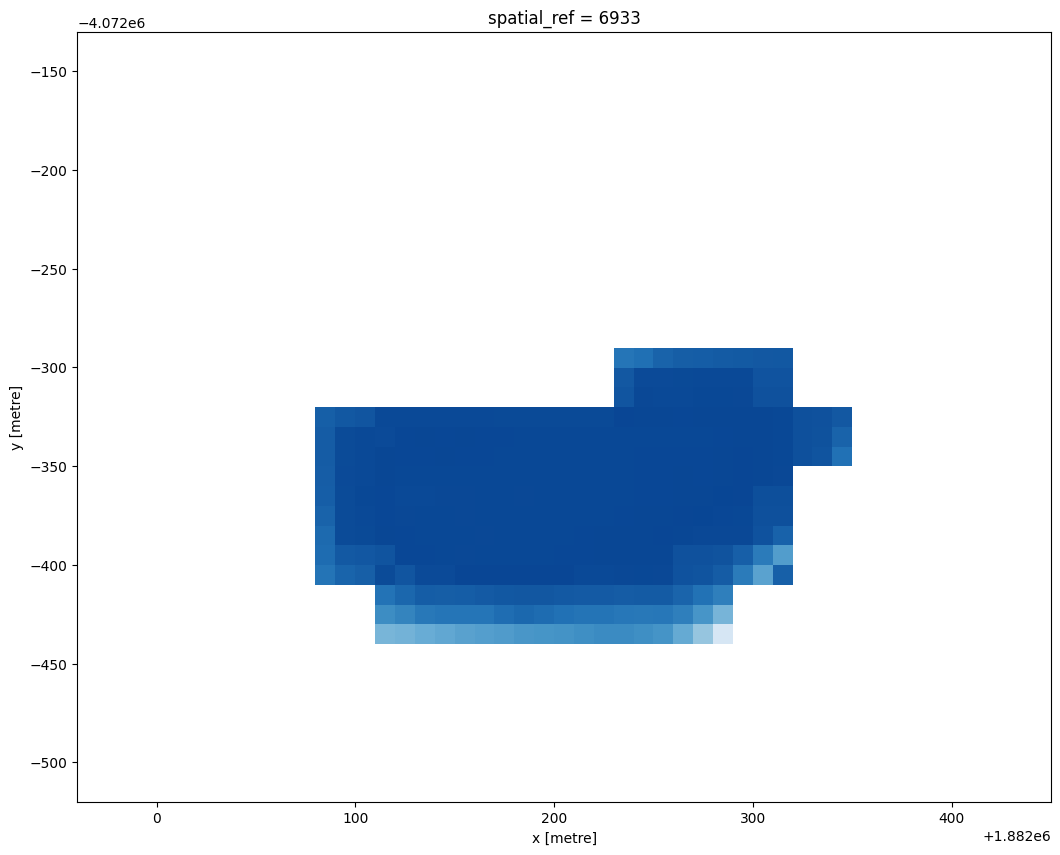

In [25]:
plot_image_with_style_cfg(custom_ramp_cfg, ds)

In [24]:
xr_image = apply_ows_style_cfg(custom_ramp_cfg, ds)

/opt/venv/lib/python3.12/site-packages/datacube_ows/styles/ramp.py:250: RuntimeWarning: invalid value encountered in cast
  return val.astype(ubyte)


In [23]:
png_image = xarray_image_as_png(xr_image)

In [24]:
with open("example1.png", "wb") as fp:
     fp.write(png_image)